# Spatially anisotropic firing: direction-resolved synchrony over distance

Self-contained analysis of how the spatial **anisotropy of coordinated firing**
develops over DIV in the `stim_removal_null` dataset (the recordings Figure 4
compiles). It keeps the *orientation* of every electrode pair — which the scalar
synchrony-vs-distance pipeline discards — so anisotropy becomes measurable.

The heavy lifting lives in the tested module `ephax.metrics.directional_synchrony`;
this notebook only loads data, drives the sweep, and draws panels.

**Panels**
1. Anisotropy magnitude vs DIV, aggregated across wells (de-confounded cos2θ
   amplitude, "option A"), under the conservative interval-jitter null.
2. Axis-aligned orientation curves per DIV (each well rotated to its own axis,
   then pooled) — shows the orientation-dependent radial reach emerging over DIV.
3. Orientation-resolved conditional firing probability and excess synchrony vs
   distance for one recording (cyclic colormap; raw, not demeaned, so the radial
   structure is preserved).

> Each well has its **own** anisotropy axis, so we aggregate the axis-invariant
> *magnitude* across wells and only pool the *curves* after aligning each well to
> its own axis — pooling raw orientations would cancel the signal.


In [61]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

repo_root = Path.cwd()
if not (repo_root / "ephax").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from ephax.metrics import ActivityIntervalConfig, detect_activity_intervals, weighted_event_bootstrap
from ephax.metrics.directional_synchrony import (
    DirectionalSyncConfig,
    compute_directional_synchrony,
    cos2_amplitude_from_grid,
    cos2_anisotropy_index,
    orientation_shuffle_pvalue,
    align_to_axis,
    orientation_distance_profile,
    pooled_anisotropy_across_wells,
    pooled_distance_curve,
    pooled_orientation_distance_grid,
)

## Configuration

In [62]:
DATA_ROOT = repo_root / "ephax" / "data" / "stimRemovalNull"
FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"

DIVS = [12, 14, 21]
WELLS = [0, 1, 2, 3, 4, 5]
WINDOW_S = (0.0, 600.0)          # START_SEC, END_SEC (matches the Figure-4 pipeline)
TOP_N_ELECTRODES = 1000          # TOP_STOP for stim_removal_null

# Anisotropy index is fit over a coverage-complete distance range (full orientation
# coverage needs distances within the array's short dimension). The radial curves
# still run to MAX_DISTANCE_UM so the ~2540 um model wavelength stays visible.
INDEX_DISTANCE_UM = (150.0, 3500.0)
RING_UM = 200.0

# Within-culture pooling: all wells come from the same embryonic specimen, so we
# aggregate by pooling activity *events* across wells (the unit of replication)
# rather than taking a CI over n=6 well means. The amplitude is fit on a pooled
# orientation x distance grid and its CI comes from an event-level bootstrap; each
# well's grid is aligned to its own axis first so the axes do not cancel.
N_AMP_ORIENT_BINS = 12
AMP_ORIENT_EDGES = np.linspace(0.0, np.pi, N_AMP_ORIENT_BINS + 1)
AMP_DIST_EDGES = np.arange(INDEX_DISTANCE_UM[0], INDEX_DISTANCE_UM[1] + RING_UM, RING_UM)
N_BOOT = 100

# Activity-interval detection uses the dedicated burst.py pipeline (population IFR +
# MAD threshold), the same path Figure 4 drives via `detect_activity_intervals`.
# `activity_scope` picks high-activity ("high_activity_all") vs network bursts ("burst").
ACTIVITY = ActivityIntervalConfig(
    activity_scope="burst",
    ifr_grid_hz=50.0,
    smooth_sigma_sec=0.15,
    high_activity_mad_scale=3.0,
    high_activity_min_duration_ms=30.0,
    network_bin_ms=10.0,
)

# Synchrony / null settings. interval_jitter is the conservative confirmatory null;
# switch to "rate_expectation" for a fast (~1 s/recording) preview.
SYNC = DirectionalSyncConfig(
    matrix_bin_ms=1.0,
    lag_window_ms=(-2.0, 2.0),
    null_method="interval_jitter",
    jitter_ms=25.0,
    n_surrogates=50,
    min_trigger_spikes=5,
    min_distance_um=50.0,
    max_distance_um=3500.0,
    n_orientation_bins=12,
    index_distance_um=INDEX_DISTANCE_UM,
    index_ring_um=RING_UM,
    random_seed=0,
)

# Fast preview: subset wells/DIVs and use the closed-form null. Set False for the
# full jitter result (~15-20 min for 30 recordings).
SMOKE = True
if SMOKE:
    DIVS = [12, 14, 21]
    WELLS = [0, 1, 2]
    SYNC = DirectionalSyncConfig(**{**SYNC.__dict__, "null_method": "rate_expectation"})

OUTPUT_DIR = repo_root / "outputs" / "directional_synchrony"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CMAP = plt.get_cmap("twilight")   # cyclic: maps axial orientation so 0 deg == 180 deg

## Data loading and preprocessing helpers

In [63]:
def load_recording(path):
    """Load spike times, per-spike electrode, and electrode->(x,y) from an NPZ."""
    d = np.load(path, allow_pickle=True)
    sf = float(np.asarray(d["samp_rate"]).reshape(-1)[0])
    cm = np.asarray(d["channelmap"], dtype=float)   # columns: channel, _, electrode, x, y
    ch_to_elec = {int(c): int(e) for c, e in zip(cm[:, 0], cm[:, 2])
                  if np.isfinite(c) and np.isfinite(e)}
    coords = {int(e): (x, y) for e, x, y in zip(cm[:, 2], cm[:, 3], cm[:, 4])
              if np.isfinite(e) and np.isfinite(x) and np.isfinite(y)}
    sd = d["spike_data"]
    times = np.asarray(sd["frameno"], dtype=float) / sf
    chans = np.asarray(sd["channel"], dtype=int)
    elec = np.fromiter((ch_to_elec.get(int(c), -1) for c in chans), dtype=int, count=chans.size)
    keep = elec >= 0
    times, elec = times[keep], elec[keep]
    times = times - times.min()                      # rebase clock to spike onset
    return times, elec, coords


def make_recording(times, elec, coords):
    """Wrap raw spike arrays as a recording-like object for the burst.py pipeline."""
    electrodes = np.array(sorted(coords), dtype=int)
    layout = {
        "electrode": electrodes,
        "x": np.array([coords[int(e)][0] for e in electrodes], dtype=float),
        "y": np.array([coords[int(e)][1] for e in electrodes], dtype=float),
    }
    return SimpleNamespace(
        spikes={"time": np.asarray(times, dtype=float), "electrode": np.asarray(elec, dtype=int)},
        start_time=float(np.min(times)), end_time=float(np.max(times)), layout=layout,
    )


def activity_intervals(recording, refs):
    """Dedicated high-activity / burst interval detection via burst.py.

    Returns ``(start_s, end_s)`` tuples for `compute_pair_synchrony`. The detection
    (population IFR + MAD threshold, optional participation bursts) is the shared
    `detect_activity_intervals` pipeline; `ACTIVITY.activity_scope` picks the scope.
    """
    df = detect_activity_intervals(recording, refs, ACTIVITY)["selected_intervals"]
    return [(float(r.start_time_s), float(r.end_time_s)) for r in df.itertuples(index=False)]


def select_top_electrodes(times, elec, coords, n):
    """Top-n electrodes by spike count that have coordinates (activity scan)."""
    uniq = np.unique(elec)
    uniq = uniq[np.array([int(e) in coords for e in uniq])]
    counts = np.array([np.count_nonzero(elec == e) for e in uniq])
    return uniq[np.argsort(counts)[::-1][:n]]


def recording_path(well, div):
    return DATA_ROOT / f"well{well}" / FILENAME_TEMPLATE.format(div=div, well=well)

## Per-recording directional synchrony sweep

For each (DIV, well): select the top electrodes, detect high-activity intervals,
compute per-pair excess synchrony with orientation retained, then the de-confounded
cos2θ anisotropy amplitude/axis and the axis-aligned orientation×distance profiles.


In [64]:
records = []          # one row per (div, well): per-well amplitude, axis, n_pairs
ex_grids = {d: [] for d in DIVS}   # axis-aligned excess profiles (curves)
po_grids = {d: [] for d in DIVS}   # axis-aligned p_obs profiles (curves)
amp_grids = {d: [] for d in DIVS}  # per-event grids in each well's OWN axis frame (amplitude)
abs_grids = {d: [] for d in DIVS}  # per-event grids in ABSOLUTE orientation (physical axis)
dist_edges = np.arange(SYNC.min_distance_um, SYNC.max_distance_um + RING_UM, RING_UM)
dist_centers = 0.5 * (dist_edges[:-1] + dist_edges[1:])
N_CURVE_BINS = 6

for div in DIVS:
    for well in WELLS:
        path = recording_path(well, div)
        times, elec, coords = load_recording(path)
        win = (times >= WINDOW_S[0]) & (times <= WINDOW_S[1])
        times, elec = times[win], elec[win]
        selected = select_top_electrodes(times, elec, coords, TOP_N_ELECTRODES)
        recording = make_recording(times, elec, coords)
        intervals = activity_intervals(recording, selected)

        # one pass: per-pair synchrony (curves) + per-event grids, both axis-aligned
        # (for the amplitude) and in absolute orientation (for the physical-axis views)
        ps, grids, grids_abs = compute_directional_synchrony(
            times, elec, coords, selected, intervals, SYNC,
            np.random.default_rng(SYNC.random_seed),
            orientation_edges=AMP_ORIENT_EDGES, distance_edges=AMP_DIST_EDGES,
            absolute_grids=True)
        amp_grids[div].append(grids)
        abs_grids[div].append(grids_abs)

        idx = cos2_anisotropy_index(ps.excess, ps.distance_um, ps.angle_rad,
                                    distance_range=INDEX_DISTANCE_UM, ring_um=RING_UM)
        records.append({"div": div, "well": well, "amplitude": idx["amplitude"],
                        "axis_deg": idx["axis_deg"], "n_pairs": idx["n_pairs"],
                        "n_events": int(grids.sum_excess.shape[0]),
                        "active_s": sum(b - a for a, b in intervals)})
        if np.isfinite(idx["axis_rad"]):
            rel = align_to_axis(ps.angle_rad, idx["axis_rad"])   # orientation vs this well's axis
            ex_grids[div].append(orientation_distance_profile(
                ps.excess, ps.distance_um, rel, n_orientation_bins=N_CURVE_BINS,
                distance_edges=dist_edges, min_pairs_per_cell=20)["grid"])
            po_grids[div].append(orientation_distance_profile(
                ps.p_obs, ps.distance_um, rel, n_orientation_bins=N_CURVE_BINS,
                distance_edges=dist_edges, min_pairs_per_cell=20)["grid"])
        print(f"DIV{div} well{well}: amp={idx['amplitude']:.4f} axis={idx['axis_deg']:.0f} deg "
              f"n_pairs={idx['n_pairs']} n_events={int(grids.sum_excess.shape[0])}", flush=True)

index_df = pd.DataFrame(records)
index_df.to_csv(OUTPUT_DIR / "anisotropy_index_by_recording.csv", index=False)

# Within-culture pooled amplitude per DIV: pool events across wells, bootstrap events.
pooled_by_div = {}
pooled_rows = []
for div in DIVS:
    pooled = pooled_anisotropy_across_wells(amp_grids[div], n_boot=N_BOOT, seed=SYNC.random_seed,
                                            distance_range=INDEX_DISTANCE_UM)
    pooled_by_div[div] = pooled
    pooled_rows.append({"div": div, "amplitude": pooled["amplitude"],
                        "ci_lo": pooled["ci_lo"], "ci_hi": pooled["ci_hi"], "se": pooled["se"],
                        "n_events": pooled["n_events"], "n_wells": pooled["n_wells"]})
pooled_df = pd.DataFrame(pooled_rows)
pooled_df.to_csv(OUTPUT_DIR / "anisotropy_pooled_by_div.csv", index=False)
pooled_df

DIV12 well0: amp=0.0017 axis=39 deg n_pairs=922874 n_events=128
DIV12 well1: amp=0.0019 axis=27 deg n_pairs=953058 n_events=123
DIV12 well2: amp=0.0002 axis=8 deg n_pairs=903850 n_events=90
DIV14 well0: amp=0.0051 axis=136 deg n_pairs=971394 n_events=124
DIV14 well1: amp=0.0159 axis=107 deg n_pairs=982800 n_events=136
DIV14 well2: amp=0.0080 axis=43 deg n_pairs=977063 n_events=92
DIV21 well0: amp=0.0196 axis=137 deg n_pairs=891334 n_events=69
DIV21 well1: amp=0.0014 axis=144 deg n_pairs=836590 n_events=88
DIV21 well2: amp=0.0043 axis=103 deg n_pairs=675479 n_events=66


,div,amplitude,ci_lo,ci_hi,se,n_events,n_wells
0,12,0.000587,0.000288,0.000920,0.000172,341,3
1,14,0.008422,0.005629,0.011755,0.001642,352,3
2,21,0.004909,0.001072,0.011877,0.002871,223,3


## Panel 1 — anisotropy magnitude vs DIV (within-culture event pooling)

All wells share one embryonic specimen, so the primary estimate pools activity
**events** across wells and the band is a 95 % CI from an event-level bootstrap —
far more power than a CI over n=6 well means. The per-well grid amplitudes are kept
as a gray overlay so between-well spread stays visible. (This is a within-culture
interval, not cross-culture inference.)

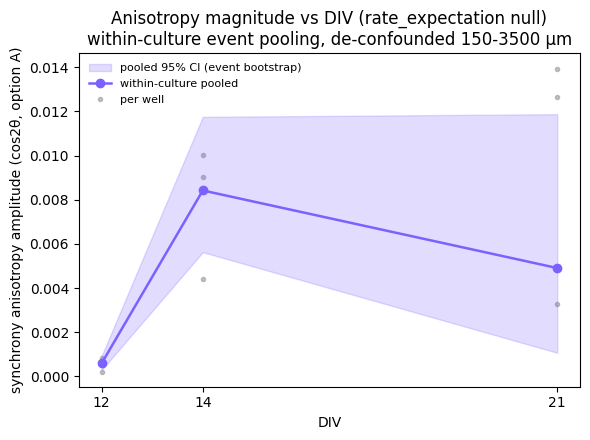

In [65]:
fig, ax = plt.subplots(figsize=(6, 4.5))
divs_arr = pooled_df["div"].to_numpy(float)
amp = pooled_df["amplitude"].to_numpy(float)
lo = pooled_df["ci_lo"].to_numpy(float)
hi = pooled_df["ci_hi"].to_numpy(float)

ax.fill_between(divs_arr, lo, hi, color="#7b61ff", alpha=0.22,
                label="pooled 95% CI (event bootstrap)")
ax.plot(divs_arr, amp, "o-", lw=1.8, ms=6, color="#7b61ff", label="within-culture pooled")
for div in DIVS:
    pw = np.asarray(pooled_by_div[div]["per_well_amplitude"], dtype=float)
    pw = pw[np.isfinite(pw)]
    ax.plot([div] * pw.size, pw, "o", ms=3, color="0.6", alpha=0.6, zorder=0,
            label="per well" if div == DIVS[0] else None)
ax.set_xlabel("DIV")
ax.set_ylabel("synchrony anisotropy amplitude (cos2θ, option A)")
ax.set_title(f"Anisotropy magnitude vs DIV ({SYNC.null_method} null)\n"
             f"within-culture event pooling, de-confounded "
             f"{INDEX_DISTANCE_UM[0]:.0f}-{INDEX_DISTANCE_UM[1]:.0f} µm")
ax.set_xticks(DIVS)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "anisotropy_amplitude_vs_div.png", dpi=130)
plt.show()

## Panel 2 — axis-aligned orientation curves per DIV (3 sectors, with CI)

Each well is rotated to its own anisotropy axis, then events are pooled across wells. The
relative-orientation bins are folded by axial symmetry into **3 sectors** — **0/180°** (along
the axis), **45°**, and **90°** (orthogonal). Each curve shows excess synchrony vs distance
with an **event-level bootstrap 95 % CI band** (`pooled_distance_curve` restricted to the
sector's bins, same machinery as Panels 2c/2d). Symlog y keeps the long-range below-chance troughs.

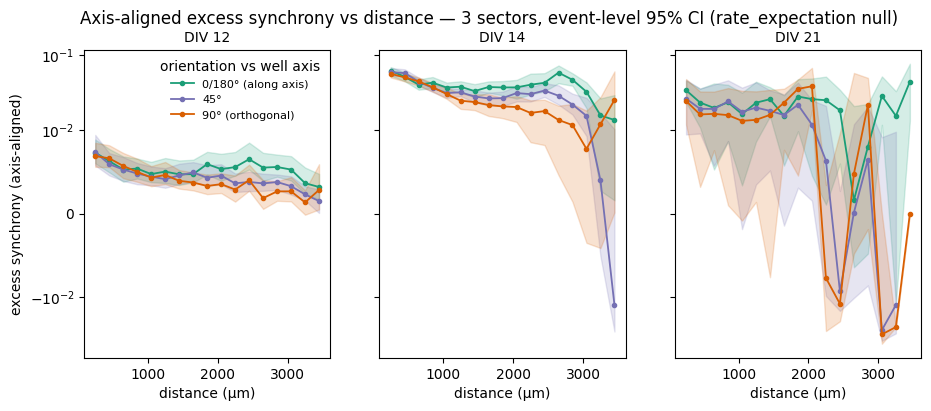

In [66]:
# Axis-aligned excess synchrony vs distance in 3 orientation sectors, with event-level CIs.
# Sectors are the 12 relative-orientation bins folded by axial symmetry: 0/180 (along axis),
# 45, and 90 (orthogonal). Each curve + CI band is the event bootstrap (pooled_distance_curve
# restricted to that sector's bins), consistent with Panels 2c/2d.
oc_deg = np.degrees(0.5 * (AMP_ORIENT_EDGES[:-1] + AMP_ORIENT_EDGES[1:]))   # relative orientation
SECTOR_BINS = [
    [i for i, a in enumerate(oc_deg) if a < 30.0 or a >= 150.0],            # along axis (0/180)
    [i for i, a in enumerate(oc_deg) if (30.0 <= a < 60.0) or (120.0 <= a < 150.0)],  # 45
    [i for i, a in enumerate(oc_deg) if 60.0 <= a < 120.0],                 # orthogonal (90)
]
SECTOR_LABELS = ["0/180° (along axis)", "45°", "90° (orthogonal)"]
SECTOR_COLORS = ["#1b9e77", "#7570b3", "#d95f02"]

fig, axes = plt.subplots(1, len(DIVS), figsize=(3.6 * len(DIVS), 4.0), sharey=True)
axes = np.atleast_1d(axes)
for ax, div in zip(axes, DIVS):
    for bins, color, label in zip(SECTOR_BINS, SECTOR_COLORS, SECTOR_LABELS):
        cur = pooled_distance_curve(amp_grids[div], orientation_indices=bins,
                                    n_boot=N_BOOT, seed=SYNC.random_seed)
        d = cur["distance_centers_um"]
        ax.plot(d, cur["excess"], "-o", ms=3, lw=1.3, color=color, label=label)
        ax.fill_between(d, cur["ci_lo"], cur["ci_hi"], color=color, alpha=0.18)
    ax.set_yscale("symlog", linthresh=0.01)
    ax.set_title(f"DIV {div}", fontsize=10)
    ax.set_xlabel("distance (µm)")
axes[0].set_ylabel("excess synchrony (axis-aligned)")
axes[0].legend(frameon=False, fontsize=8, title="orientation vs well axis")
fig.suptitle(f"Axis-aligned excess synchrony vs distance — 3 sectors, event-level 95% CI ({SYNC.null_method} null)")
fig.savefig(OUTPUT_DIR / "aligned_orientation_curves_by_div.png", dpi=120, bbox_inches="tight")
plt.show()

## Panel 2b — radial (polar) view in **absolute** orientation, with the dominant axis marked

Excess synchrony as a polar map in *physical* orientation (pooled over wells, **not**
axis-aligned): angle = absolute pair orientation (0° = +x / horizontal, 90° = +y / vertical,
axial so mirrored to the full circle), radius = distance, color = mean excess. The **dashed
spoke** marks the **dominant axis** — the absolute orientation of highest average synchrony
(cos2θ peak of the pooled absolute grid, fit over the coverage-complete distance range so
incomplete far-radius coverage doesn't bias it). A coherent lobe along the dashed line means
the wells share that physical axis.

Caveats stay physically meaningful: the model band (~2000–3000 µm) only has pairs along the
array's long side, and vertical (~90°) pairs vanish beyond the short dimension; sparse cells
(<10 % of peak pair count) are masked.

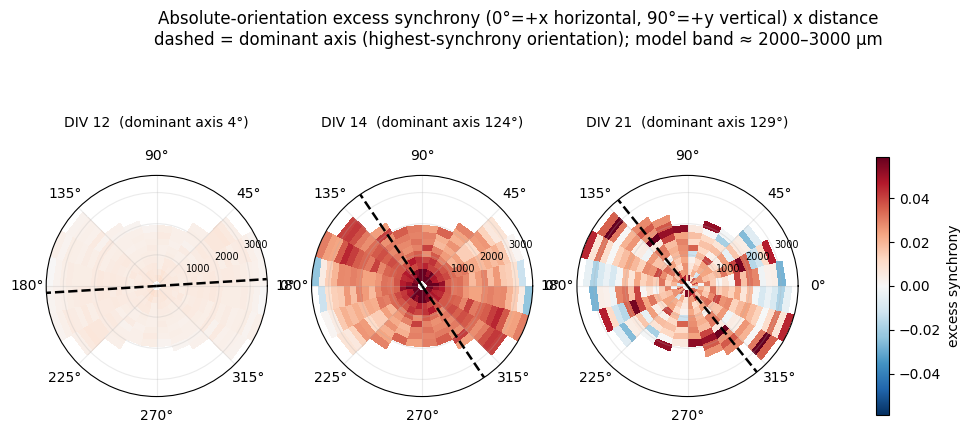

In [67]:
# Absolute-orientation polar view: physical angle (0 deg = +x/horizontal, 90 deg = +y/
# vertical, axial -> full circle), radius = distance, color = mean excess synchrony.
# Pooled across wells in ABSOLUTE orientation. The DOMINANT AXIS (orientation of highest
# average synchrony) is the cos2theta peak of the pooled absolute grid, estimated over the
# coverage-complete distance range, and drawn as a dashed spoke on each DIV.
from matplotlib.colors import TwoSlopeNorm

# Dominant axis is fit only where every orientation has pairs (within the array's short
# dimension); beyond that, coverage is horizontal-only and would bias the angle.
DOMINANT_RANGE = (INDEX_DISTANCE_UM[0], 2000.0)
COUNT_FRAC = 0.10   # mask orientation x distance cells with < 10% of the peak pair count

grids_by_div = {div: pooled_orientation_distance_grid(abs_grids[div]) for div in DIVS}
dom_axis = {}
for div, g in grids_by_div.items():
    if g is None:
        dom_axis[div] = np.nan
        continue
    dom_axis[div] = cos2_amplitude_from_grid(
        g["grid"], g["orientation_centers_rad"], g["distance_centers_um"],
        weights=g["count"], distance_range=DOMINANT_RANGE)["axis_rad"]
    thr = COUNT_FRAC * np.nanmax(g["count"])
    g["grid"] = np.where(g["count"] >= thr, g["grid"], np.nan)

allv = np.concatenate([g["grid"].ravel() for g in grids_by_div.values() if g is not None])
vmax = float(np.nanpercentile(np.abs(allv), 98)) or 1e-6
full_theta_edges = np.concatenate([AMP_ORIENT_EDGES, AMP_ORIENT_EDGES[1:] + np.pi])  # [0, 2pi)

fig, axes = plt.subplots(1, len(DIVS), figsize=(4.2 * len(DIVS), 4.8),
                         subplot_kw={"projection": "polar"})
axes = np.atleast_1d(axes)
pcm = None
for ax, div in zip(axes, DIVS):
    g = grids_by_div[div]
    th = dom_axis[div]
    ax.set_title(f"DIV {div}" + (f"  (dominant axis {np.degrees(th):.0f}°)" if np.isfinite(th) else ""),
                 fontsize=10, pad=16)
    if g is None:
        continue
    mirror = np.concatenate([g["grid"], g["grid"]], axis=0)        # axial -> full circle
    pcm = ax.pcolormesh(full_theta_edges, AMP_DIST_EDGES, mirror.T,
                        cmap="RdBu_r", norm=TwoSlopeNorm(0.0, -vmax, vmax), shading="flat")
    if np.isfinite(th):
        for t in (th, th + np.pi):
            ax.plot([t, t], [0, AMP_DIST_EDGES[-1]], color="k", lw=1.8, ls="--", zorder=5)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_rgrids([1000, 2000, 3000], angle=22.5, fontsize=7)
    ax.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315])
    ax.grid(True, alpha=0.25)
if pcm is not None:
    cb = fig.colorbar(pcm, ax=axes, shrink=0.7, pad=0.08)
    cb.set_label("excess synchrony")
fig.suptitle("Absolute-orientation excess synchrony (0°=+x horizontal, 90°=+y vertical) x distance\n"
             "dashed = dominant axis (highest-synchrony orientation); model band ≈ 2000–3000 µm", y=1.07)
fig.savefig(OUTPUT_DIR / "radial_absolute_orientation_synchrony_by_div.png", dpi=120, bbox_inches="tight")
plt.show()

## Panel 2c — orientation-collapsed excess synchrony vs distance (event-level CI)

The same excess synchrony as Panel 2 but with the **angle thrown away**: every pair in
a distance ring contributes, pooled over all orientations. The band is a 95 % CI from
the event-level bootstrap (`pooled_distance_curve`) — with events (not n=6 well means)
as the unit of replication, it is much narrower than a per-well CI.

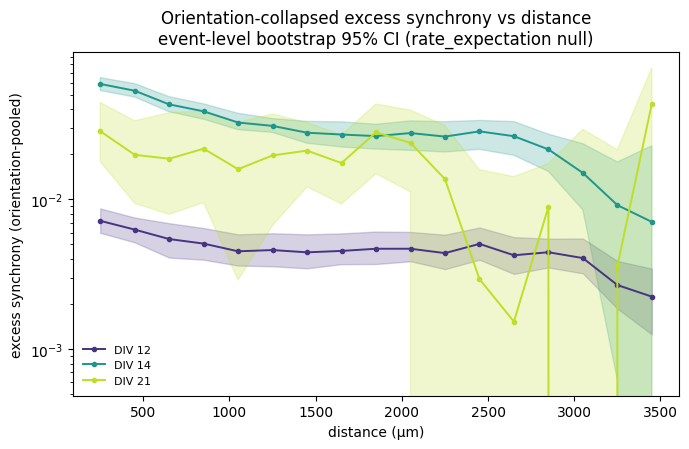

In [68]:
# Orientation-collapsed (isotropic) excess synchrony vs distance: angle is discarded so
# every pair in a distance ring contributes, and the CI is the event-level bootstrap —
# much tighter than a per-well-mean band thanks to the larger event-level n.
fig, ax = plt.subplots(figsize=(7, 4.6))
colors = plt.get_cmap("viridis")(np.linspace(0.15, 0.9, len(DIVS)))
for color, div in zip(colors, DIVS):
    cur = pooled_distance_curve(amp_grids[div], n_boot=N_BOOT, seed=SYNC.random_seed)
    d = cur["distance_centers_um"]
    ax.plot(d, cur["excess"], "-o", ms=3, lw=1.4, color=color, label=f"DIV {div}")
    ax.fill_between(d, cur["ci_lo"], cur["ci_hi"], color=color, alpha=0.22)
ax.set_yscale("symlog", linthresh=0.01)
ax.set_xlabel("distance (µm)")
ax.set_ylabel("excess synchrony (orientation-pooled)")
ax.set_yscale("log")
ax.set_title("Orientation-collapsed excess synchrony vs distance\n"
             f"event-level bootstrap 95% CI ({SYNC.null_method} null)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "isotropic_excess_vs_distance_by_div.png", dpi=130)
plt.show()

## Panel 2d — dominant-axis vs orthogonal sector curves

Excess synchrony vs distance split by **absolute** orientation around the **data-driven
dominant axis** (`dom_axis[div]` from Panel 2b — the orientation of highest average
synchrony): the dominant sector is the absolute bins within ±30° of that axis, the orthogonal
sector the bins within ±30° of dominant + 90°. Pooled across wells, event-level CIs, model
band (~2000–3000 µm) shaded. The spatial anisotropy is the **dominant − orthogonal gap**, and
its growth/reach over DIV is the development we want to show.

> *Caveat:* the dominant axis is estimated from the same pooled data, so the dominant sector
> is favored by construction (the gap is biased slightly positive even under isotropy). The
> *change* in the gap across DIV is the meaningful signal; for an unbiased gap, estimate the
> axis on held-out events and measure the sectors on the rest.

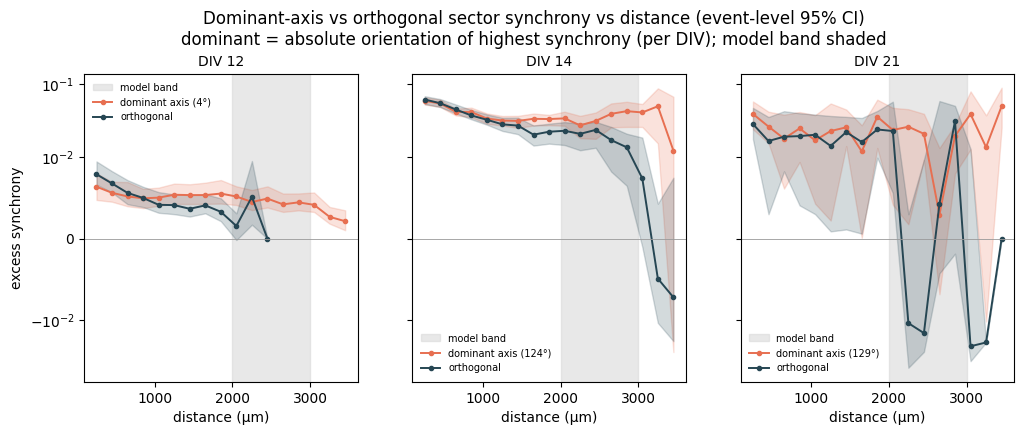

In [69]:
# Dominant vs orthogonal sector curves, referenced to the DATA-DRIVEN dominant axis.
# `dom_axis[div]` (from Panel 2b) is the absolute orientation of highest average synchrony;
# the dominant sector is the absolute bins within +/-30 deg of it, the orthogonal sector the
# bins within +/-30 deg of dom_axis + 90 deg. Curves use the absolute grids, pooled across
# wells, with event-level bootstrap CIs; the model band (~2000-3000 um) is shaded.
abs_centers = pooled_orientation_distance_grid(abs_grids[DIVS[0]])["orientation_centers_rad"]
BAND_UM = (2000.0, 3000.0)

def _axial_bins_near(centers_rad, target_rad, half_deg=30.0):
    """Indices of orientation bins within +/-half_deg of target (axial, mod pi)."""
    d = np.degrees(np.angle(np.exp(2j * (np.asarray(centers_rad) - target_rad))) / 2.0)
    return [i for i in range(len(centers_rad)) if abs(d[i]) <= half_deg]

fig, axes = plt.subplots(1, len(DIVS), figsize=(4.0 * len(DIVS), 4.0), sharey=True)
axes = np.atleast_1d(axes)
for ax, div in zip(axes, DIVS):
    th = dom_axis[div]
    ax.axvspan(*BAND_UM, color="0.85", alpha=0.6, zorder=0, label="model band")
    if np.isfinite(th):
        dominant_bins = _axial_bins_near(abs_centers, th)
        orthogonal_bins = _axial_bins_near(abs_centers, th + np.pi / 2)
        for bins, color, label in [(dominant_bins, "#e76f51", f"dominant axis ({np.degrees(th):.0f}°)"),
                                   (orthogonal_bins, "#264653", "orthogonal")]:
            cur = pooled_distance_curve(abs_grids[div], orientation_indices=bins,
                                        n_boot=N_BOOT, seed=SYNC.random_seed)
            d = cur["distance_centers_um"]
            ax.plot(d, cur["excess"], "-o", ms=3, lw=1.4, color=color, label=label)
            ax.fill_between(d, cur["ci_lo"], cur["ci_hi"], color=color, alpha=0.2)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_yscale("symlog", linthresh=0.01)
    ax.set_title(f"DIV {div}", fontsize=10)
    ax.set_xlabel("distance (µm)")
    ax.legend(frameon=False, fontsize=7)
axes[0].set_ylabel("excess synchrony")
fig.suptitle("Dominant-axis vs orthogonal sector synchrony vs distance (event-level 95% CI)\n"
             "dominant = absolute orientation of highest synchrony (per DIV); model band shaded", y=1.04)
fig.savefig(OUTPUT_DIR / "sector_excess_vs_distance_by_div.png", dpi=120, bbox_inches="tight")
plt.show()

## Panel A — firing-rate map over the HD-MEA (raw rate, per DIV)

Mean per-electrode **firing rate (Hz, not normalized)**, grid-binned over the MaxTwo well
(nominal sensor ~3850 × 2100 µm) and averaged across wells per DIV.

**Selection-bias correction.** The activity scan only routes the most active electrodes, so a
grid bin with no recorded electrode sat *below the scan threshold* — its true rate is ≤ the
lowest recorded rate in that recording. Empty bins are therefore **imputed to a conservative
floor (the recording's minimum recorded rate)** rather than dropped. Otherwise a bin that is
empty in most wells but routed in one or two reads as that single high value, inflating the
middle and horizontal fringes of the array. Wells are averaged **equally** so the imputed lows
contribute (printed: the fraction of bins imputed per DIV).

Each DIV is a joint plot (rate map + its own x/y marginals, 95 % CI across wells); the second
figure overlays the x- and y-marginals across DIV in color for direct comparison of how the
spatial profile develops.

MEA extent: x 18-3832 um, y 18-2082 um (nominal MaxTwo 3850x2100); grid 16x9 @ 250 um
fraction of grid bins imputed (no recorded electrode) per DIV: {12: 0.12, 14: 0.14, 21: 0.15}


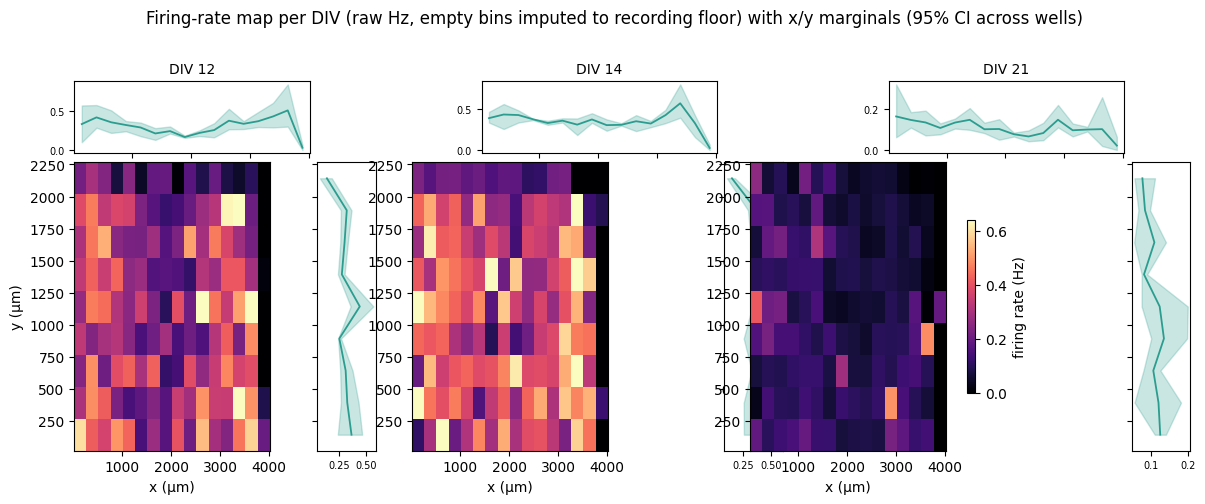

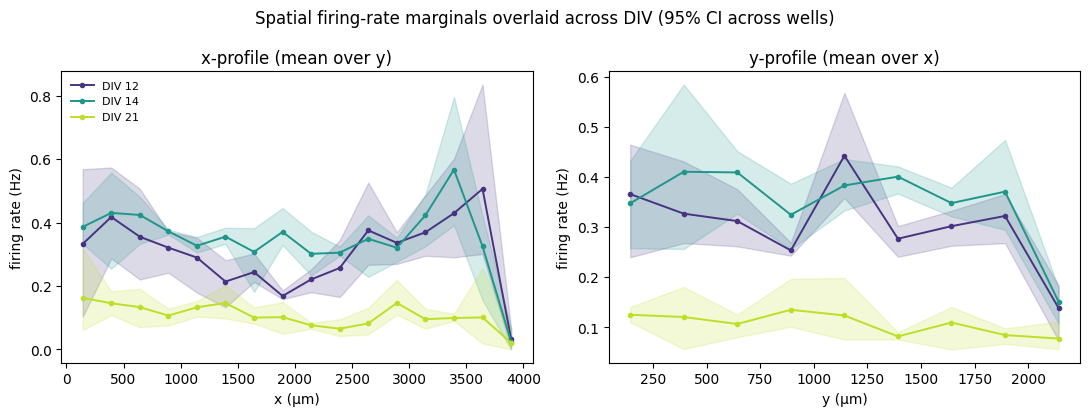

In [70]:
# Raw firing-rate map over the HD-MEA (MaxTwo well; nominal sensor ~3850 x 2100 um).
# Per-electrode rate in Hz (NOT normalized), grid-binned over the recorded-electrode extent.
#
# Selection-bias correction: the activity scan only routes the most active electrodes, so a
# grid bin with NO recorded electrode was below the scan threshold -> its true rate is <= the
# lowest recorded rate in that recording. We therefore IMPUTE empty bins to a conservative
# floor (the recording's minimum recorded rate) instead of dropping them (NaN). Without this,
# a bin that is empty in most wells but routed in one or two reads as that well's high value,
# biasing the middle and horizontal fringes upward. Wells are then averaged equally so the
# imputed lows actually contribute.
GRID_BIN_UM = 250.0
MEA_NOMINAL_UM = (3850.0, 2100.0)   # MaxTwo well sensor (x, y), for reference

def recording_rate(times, elec, coords):
    dur = max(float(times.max() - times.min()), 1e-9)
    uniq = np.array(sorted(coords), dtype=int)
    vals, counts = np.unique(elec, return_counts=True)
    cnt = dict(zip(vals.tolist(), counts.tolist()))
    rate_hz = np.array([cnt.get(int(e), 0) for e in uniq], dtype=float) / dur
    xy = np.array([coords[int(e)] for e in uniq], dtype=float)
    return xy, rate_hz

fr_recs, xs, ys = {}, [], []
for div in DIVS:
    for well in WELLS:
        t, e, coords = load_recording(recording_path(well, div))
        w = (t >= WINDOW_S[0]) & (t <= WINDOW_S[1]); t, e = t[w], e[w]
        xy, rate = recording_rate(t, e, coords)
        fr_recs[(div, well)] = (xy, rate); xs.append(xy[:, 0]); ys.append(xy[:, 1])
xs = np.concatenate(xs); ys = np.concatenate(ys)
# array boundary = recorded-electrode extent; do not bin/resolve beyond the MaxTwo sensor
x_edges = np.arange(xs.min(), xs.max() + GRID_BIN_UM, GRID_BIN_UM)
y_edges = np.arange(ys.min(), ys.max() + GRID_BIN_UM, GRID_BIN_UM)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:]); y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
nbx, nby = x_centers.size, y_centers.size
print(f"MEA extent: x {xs.min():.0f}-{xs.max():.0f} um, y {ys.min():.0f}-{ys.max():.0f} um "
      f"(nominal MaxTwo {MEA_NOMINAL_UM[0]:.0f}x{MEA_NOMINAL_UM[1]:.0f}); grid {nbx}x{nby} @ {GRID_BIN_UM:.0f} um")

def bin_grid_filled(xy, rate):
    """Mean recorded rate per bin; bins with no recorded electrode imputed to the recording
    floor (its minimum recorded rate), since unrouted sites were below the activity scan."""
    xi = np.clip(np.searchsorted(x_edges, xy[:, 0], "right") - 1, 0, nbx - 1)
    yi = np.clip(np.searchsorted(y_edges, xy[:, 1], "right") - 1, 0, nby - 1)
    s = np.zeros((nby, nbx)); c = np.zeros((nby, nbx))
    np.add.at(s, (yi, xi), rate); np.add.at(c, (yi, xi), 1.0)
    floor = float(np.min(rate)) if rate.size else 0.0
    with np.errstate(invalid="ignore"):
        grid = np.where(c > 0, s / np.where(c > 0, c, 1.0), floor)
    return grid, c

fr_grid_by_div, fr_xprof, fr_yprof, fr_imputed_frac = {}, {}, {}, {}
for div in DIVS:
    grids, xprofs, yprofs, empty = [], [], [], []
    for well in WELLS:
        g, c = bin_grid_filled(*fr_recs[(div, well)])
        grids.append(g)
        xprofs.append(g.mean(axis=0)); yprofs.append(g.mean(axis=1))   # no NaN: every bin defined
        empty.append(np.mean(c == 0))
    fr_grid_by_div[div] = np.mean(np.array(grids), axis=0)
    # wells weighted equally (the imputed lows must count), bootstrap over wells
    ones = np.ones((len(WELLS), nbx))
    fr_xprof[div] = weighted_event_bootstrap(np.array(xprofs), ones, n_boot=N_BOOT, seed=SYNC.random_seed)
    fr_yprof[div] = weighted_event_bootstrap(np.array(yprofs), np.ones((len(WELLS), nby)),
                                             n_boot=N_BOOT, seed=SYNC.random_seed)
    fr_imputed_frac[div] = float(np.mean(empty))
print("fraction of grid bins imputed (no recorded electrode) per DIV:",
      {d: round(fr_imputed_frac[d], 2) for d in DIVS})

# per-DIV joint plots: raw-Hz heatmap with its own x/y marginal profiles (shared color scale)
vmax = float(np.nanpercentile(np.concatenate([fr_grid_by_div[d].ravel() for d in DIVS]), 98))
fig = plt.figure(figsize=(4.8 * len(DIVS), 4.8))
outer = fig.add_gridspec(1, len(DIVS), wspace=0.35)
main_axes, im = [], None
for col, div in enumerate(DIVS):
    inner = outer[0, col].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                      wspace=0.05, hspace=0.05)
    axm = fig.add_subplot(inner[1, 0])
    axt = fig.add_subplot(inner[0, 0], sharex=axm)
    axr = fig.add_subplot(inner[1, 1], sharey=axm)
    main_axes.append(axm)
    im = axm.imshow(fr_grid_by_div[div], origin="lower", aspect="auto", cmap="magma",
                    vmin=0.0, vmax=vmax, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
    axm.set_xlabel("x (µm)")
    if col == 0:
        axm.set_ylabel("y (µm)")
    xp = fr_xprof[div]
    axt.plot(x_centers, xp["point"], color="#2a9d8f", lw=1.3)
    axt.fill_between(x_centers, xp["ci_lo"], xp["ci_hi"], color="#2a9d8f", alpha=0.25)
    axt.set_title(f"DIV {div}", fontsize=10)
    plt.setp(axt.get_xticklabels(), visible=False); axt.tick_params(labelsize=7)
    yp = fr_yprof[div]
    axr.plot(yp["point"], y_centers, color="#2a9d8f", lw=1.3)
    axr.fill_betweenx(y_centers, yp["ci_lo"], yp["ci_hi"], color="#2a9d8f", alpha=0.25)
    plt.setp(axr.get_yticklabels(), visible=False); axr.tick_params(labelsize=7)
cb = fig.colorbar(im, ax=main_axes, shrink=0.6, pad=0.02)
cb.set_label("firing rate (Hz)")
fig.suptitle("Firing-rate map per DIV (raw Hz, empty bins imputed to recording floor) "
             "with x/y marginals (95% CI across wells)", y=1.03)
fig.savefig(OUTPUT_DIR / "firing_rate_map_by_div.png", dpi=120, bbox_inches="tight")
plt.show()

# marginal profiles overlaid across DIV in color (one line per DIV, per spatial bin)
fig, (axx, axy) = plt.subplots(1, 2, figsize=(11, 4.2))
colors = plt.get_cmap("viridis")(np.linspace(0.15, 0.9, len(DIVS)))
for color, div in zip(colors, DIVS):
    xp, yp = fr_xprof[div], fr_yprof[div]
    axx.plot(x_centers, xp["point"], "-o", ms=3, lw=1.4, color=color, label=f"DIV {div}")
    axx.fill_between(x_centers, xp["ci_lo"], xp["ci_hi"], color=color, alpha=0.18)
    axy.plot(y_centers, yp["point"], "-o", ms=3, lw=1.4, color=color, label=f"DIV {div}")
    axy.fill_between(y_centers, yp["ci_lo"], yp["ci_hi"], color=color, alpha=0.18)
axx.set_xlabel("x (µm)"); axx.set_ylabel("firing rate (Hz)"); axx.set_title("x-profile (mean over y)")
axy.set_xlabel("y (µm)"); axy.set_ylabel("firing rate (Hz)"); axy.set_title("y-profile (mean over x)")
axx.legend(frameon=False, fontsize=8)
fig.suptitle("Spatial firing-rate marginals overlaid across DIV (95% CI across wells)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "firing_rate_marginals_overlay.png", dpi=130, bbox_inches="tight")
plt.show()

## Notes

* **Null.** `interval_jitter` (the default here) is the conservative surrogate null;
  it agrees with the fast `rate_expectation` null on the anisotropy magnitude while
  controlling slow rate covariation. Set `SMOKE = True` for a quick `rate_expectation`
  preview on a subset.
* **Within-culture event pooling (Panel 1).** All wells originate in the same
  embryonic specimen, so the aggregate pools activity **events** across wells and the
  CI comes from an event-level bootstrap (`pooled_anisotropy_across_wells`), rather
  than a noisy CI over n=6 well means. Events — not wells or pairs — are the unit of
  replication, which mirrors how the scalar synchrony path bootstraps intervals. This
  is a *within-culture* interval (n=1 specimen); it quantifies the effect in this
  preparation, not cross-culture generalization. The per-well points are retained as a
  robustness overlay.
* **Why aggregate magnitude, not raw curves.** Each well has its own anisotropy axis,
  so the pooled amplitude is fit after aligning each well's orientation x distance grid
  to *that well's* axis (axes would otherwise cancel); the curves are likewise pooled
  only after per-well axis alignment.
* **Distance ranges.** The cos2θ index is fit over a coverage-complete range
  (`INDEX_DISTANCE_UM`); beyond the array's short dimension only near-axis pairs exist,
  so the angular fit there is geometrically ill-posed. The radial curves still extend to
  `max_distance_um` to show the long-range structure.
* **Significance.** `orientation_shuffle_pvalue` gives a per-recording one-sided p-value
  by permuting orientation labels and refitting.
* **Backend reuse.** `pooled_anisotropy_across_wells` (directional) and
  `pool_distance_synchrony_across_recordings` (scalar / Figure 4) share the same
  `weighted_event_bootstrap` core, so both synchrony paths aggregate consistently.